# Предсказание растворимости на базе AqSolDB, но уже используя продвинутые модели ML

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

from rdkit import Chem
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Draw
from rdkit import DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem import PandasTools

import matplotlib.pyplot as plt

from rdkit import RDLogger
# Отключаем все логи/предупреждения RDKit
RDLogger.DisableLog('rdApp.*')

Считаем БД, оставив только колонки SMILES и Solubility

In [2]:
aqsoldb = pd.read_csv('AqSolDB.csv')

aqsoldb = aqsoldb[['SMILES', 'Solubility']]

aqsoldb

,SMILES,Solubility
0,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127
1,O=C1Nc2cccc3cccc1c23,-3.254767
2,Clc1ccc(C=O)cc1,-2.177078
3,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409
4,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065
...,...,...
9977,C(c1ccc(cc1)NCCCC)(=O)OCCN(C)C,-3.010000
9978,OC1=C(C(C2=C(O)[C@@](C(C(C(N)=O)=C(O)[C@H]3N(C...,-2.930000
9979,c1(cc(ccc1C(C)C)C)O,-2.190000
9980,COc1ccc(CCN(C)CCCC(C#N)(C(C)C)c2ccc(OC)c(OC)c2...,-3.980000


Проведем отбор валидных SMILES

In [3]:
# Определяем функцию, которая проверяет, является ли строка SMILES корректной
def is_valid_smiles(smiles):
    # Chem.MolFromSmiles пытается преобразовать строку SMILES в объект молекулы.
    # Если строка некорректна, возвращается None.
    return Chem.MolFromSmiles(smiles) is not None

# Фильтруем DataFrame aqsoldb, оставляя только те строки,
# в которых значение в столбце 'SMILES' представляет собой корректную молекулу.
# Для этого применяем функцию is_valid_smiles к каждому элементу столбца 'SMILES'.
# Метод apply() позволяет применить функцию ко всем элементам столбца.
aqsoldb = aqsoldb[aqsoldb['SMILES'].apply(is_valid_smiles)].reset_index(drop=True)

# Выводим количество оставшихся строк после фильтрации
len(aqsoldb)

9980

In [4]:
X = aqsoldb['SMILES'] #для облегчения работы можно ограничиться первой тысячей записей вместо всей БД
y = aqsoldb['Solubility'] #иначе этап расчёта всех дескрипторов может занять до 10 минут

# Делим данные на обучающую и тестовую выборки:
# - X_train: SMILES для обучения модели
# - X_test:  SMILES для тестирования модели
# - y_train: известные значения растворимости для обучения
# - y_test:  известные значения растворимости для тестирования
#
# test_size=0.2 означает, что 20% данных будет использовано для тестирования (200 из 1000)
# random_state=42 гарантирует воспроизводимость разбиения при повторных запусках
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Предобработка данных

Здесь мы создадим из полученных тренировочной и тестовой выборок массивы признаков (фичей), пригодных для обработки моделями ML

In [5]:
# Определяем функцию, которая вычисляет определённые нами дескрипторы для списка SMILES
def RDkit_descriptors_few(smiles):
    # Преобразуем каждую строку SMILES в объект молекулы (mol)
    # Chem.MolFromSmiles — это функция RDKit, которая создаёт объект молекулы из строки SMILES
    mols = [Chem.MolFromSmiles(i) for i in smiles]

    # Создаём пустой список, куда будем добавлять посчитанные дескрипторы для каждой молекулы
    Mol_descriptors = []

    # Для каждой молекулы вычисляем несколько важных дескрипторов
    for mol in mols:
        # LogP — коэффициент распределения между октанолом и водой. Мера липофильности.
        logp = Descriptors.MolLogP(mol)

        # MolWt — точная молекулярная масса соединения
        molwt = Descriptors.ExactMolWt(mol)

        # HBD — количество доноров водородных связей (по правилу Липинского)
        HBD = rdMolDescriptors.CalcNumHBD(mol)

        # HBA — количество акцепторов водородных связей (тоже по правилу Липинского)
        HBA = rdMolDescriptors.CalcNumHBA(mol)

        # Добавляем рассчитанные дескрипторы в общий список
        Mol_descriptors.append((logp, molwt, HBD, HBA))

    return Mol_descriptors

In [6]:
desc_train = RDkit_descriptors_few(X_train)
desc_test = RDkit_descriptors_few(X_test)

desc_train_np = np.array(desc_train)
non_nan_mask = ~np.isnan(desc_train_np).any(axis=1)
desc_train_clean = desc_train_np[non_nan_mask]
y_train_clean = y_train.values[non_nan_mask]

desc_test_np = np.array(desc_test)
non_nan_mask = ~np.isnan(desc_test_np).any(axis=1)
desc_test_clean = desc_test_np[non_nan_mask]
y_test_clean = y_test.values[non_nan_mask]

In [7]:
from sklearn.preprocessing import StandardScaler

# 1. Инициализируем скалер
scaler = StandardScaler()

# 2. Обучаем скалер на обучающих данных (вычисляем среднее и стандартное отклонение)
# и сразу преобразуем обучающие данные
desc_train_scaled = scaler.fit_transform(desc_train_clean)

# 3. Преобразуем тестовые данные, используя параметры, полученные на обучении
# (ВАЖНО: не используем fit_transform для теста, только transform!)
desc_test_scaled = scaler.transform(desc_test_clean)

### Воспользуемся XGBoost

In [15]:
# Создаём модель линейной регрессии

import xgboost as xgb

model = xgb.XGBRegressor(random_state=42)

# Обучаем модель на очищенных обучающих данных:

model.fit(desc_train_scaled, y_train_clean)

# Делаем предсказания на тестовых данных
# model.predict() возвращает предсказанные значения растворимости для тестовой выборки
y_pred = model.predict(desc_test_scaled)

# Вычисляем и выводим метрики качества модели

# MSE (Mean Squared Error) — среднеквадратичная ошибка
# Чем меньше — тем лучше. Показывает, насколько в среднем предсказание отличается от правильного значения.
print("  Test MSE:", mean_squared_error(y_test_clean, y_pred))

# R² (коэффициент детерминации)
# Показывает, насколько хорошо модель объясняет вариацию целевой переменной.
# Значение близкое к 1 — хорошая модель; близкое к 0 — модель плохо описывает данные.
print("  Test R2:", r2_score(y_test_clean, y_pred))

  Test MSE: 1.629774789173224
  Test R2: 0.6993913487644121


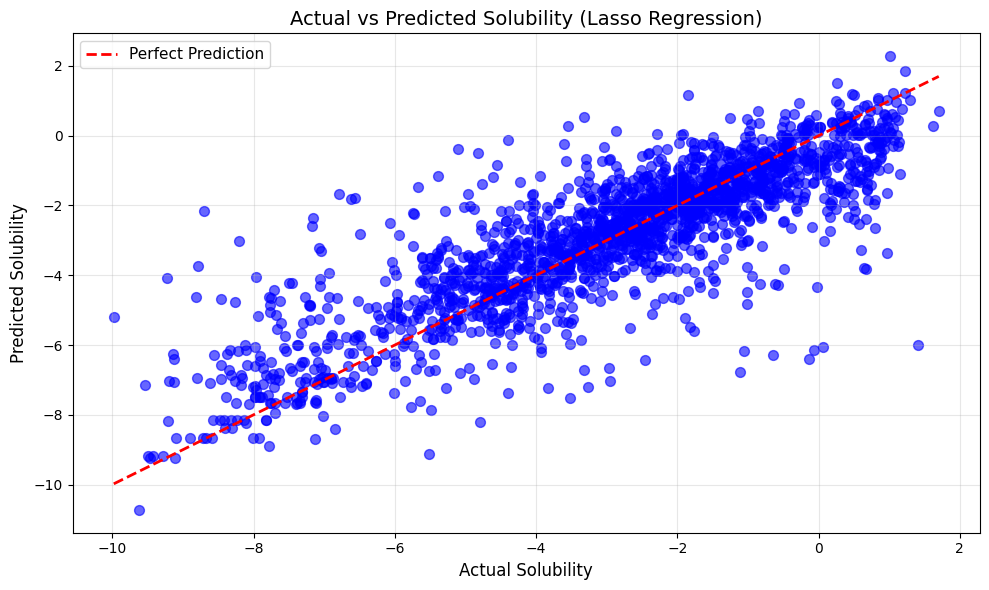

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_clean, y_pred, alpha=0.6, color='blue', s=50)
plt.plot([y_test_clean.min(), y_test_clean.max()], [y_test_clean.min(), y_test_clean.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Solubility', fontsize=12)
plt.ylabel('Predicted Solubility', fontsize=12)
plt.title('Actual vs Predicted Solubility (Lasso Regression)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Вспомни результаты для Lasso

In [17]:
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(desc_train_clean, y_train_clean)
y_pred_lasso = lasso.predict(desc_test_clean)


print("Lasso Regression:")
print("  Test MSE:", mean_squared_error(y_test_clean, y_pred_lasso))
print("  Test R2:", r2_score(y_test_clean, y_pred_lasso))

Lasso Regression:
  Test MSE: 2.871596879474097
  Test R2: 0.47033978524791054


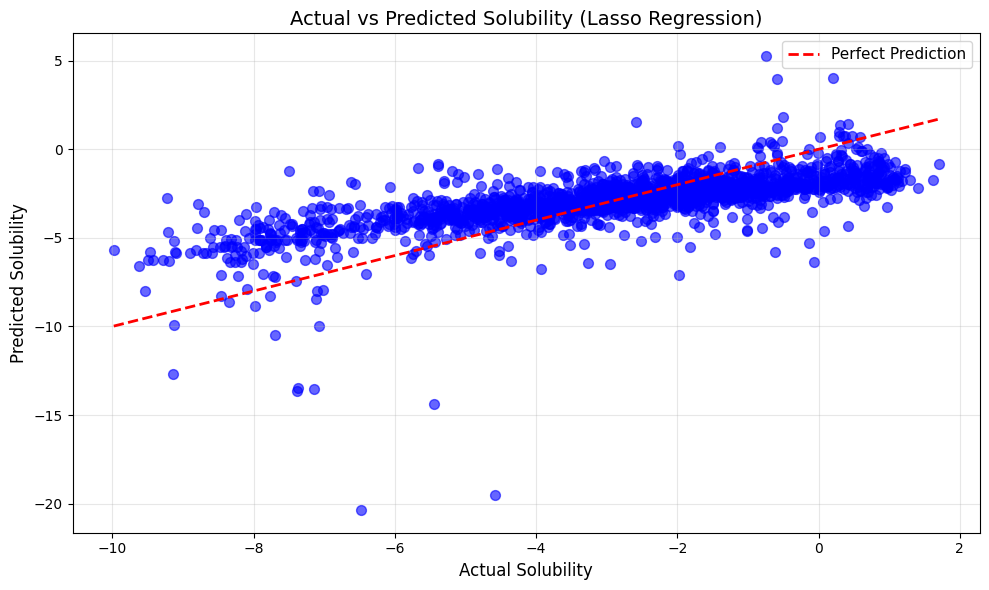

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_clean, y_pred_lasso, alpha=0.6, color='blue', s=50)
plt.plot([y_test_clean.min(), y_test_clean.max()], [y_test_clean.min(), y_test_clean.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Solubility', fontsize=12)
plt.ylabel('Predicted Solubility', fontsize=12)
plt.title('Actual vs Predicted Solubility (Lasso Regression)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
from sklearn.tree import DecisionTreeRegressor

# Создаём модель дерева решений
# Можно задать параметры, например, max_depth, чтобы избежать переобучения,
# но для "базового" дерева оставляем параметры по умолчанию.
tree_model = DecisionTreeRegressor(random_state=42)

# Обучаем модель на очищенных обучающих данных
tree_model.fit(desc_train_clean, y_train_clean)

# Делаем предсказания на тестовых данных
y_pred_tree = tree_model.predict(desc_test_clean)

# Вычисляем и выводим метрики качества модели
print("  Test MSE (Tree):", mean_squared_error(y_test_clean, y_pred_tree))
print("  Test R2 (Tree):", r2_score(y_test_clean, y_pred_tree))

  Test MSE (Tree): 2.7303071896135123
  Test R2 (Tree): 0.4964003817086222


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Создаём модель дерева решений
# Можно задать параметры, например, max_depth, чтобы избежать переобучения,
# но для "базового" дерева оставляем параметры по умолчанию.
tree_model = RandomForestRegressor(random_state=42)

# Обучаем модель на очищенных обучающих данных
tree_model.fit(desc_train_clean, y_train_clean)

# Делаем предсказания на тестовых данных
y_pred_tree = tree_model.predict(desc_test_clean)

# Вычисляем и выводим метрики качества модели
print("  Test MSE (RandomForestRegressor):", mean_squared_error(y_test_clean, y_pred_tree))
print("  Test R2 (RandomForestRegressor):", r2_score(y_test_clean, y_pred_tree))

  Test MSE (Tree): 1.5398076057512151
  Test R2 (Tree): 0.7159856131030296


# Воспользуемся снова всеми дескрипторами, но уже с XGboost

In [22]:
# Определяем функцию, которая будет рассчитывать дескрипторы RDKit для списка SMILES
def RDkit_descriptors(smiles):
    # Преобразуем каждую строку SMILES в объект молекулы (mol) с помощью RDKit
    # Мы уверены, что данная строка сработает, поскольку ранее отфильтровали невалидные SMILES
    mols = [Chem.MolFromSmiles(i) for i in smiles]

    # Создаём объект для вычисления молекулярных дескрипторов
    # [x[0] для x в Descriptors._descList] — это список названий всех доступных дескрипторов
    # Подробнее с классом MoleculeDescriptors можно ознакомиться в RDKit
    calc = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])

    # Получаем имена всех дескрипторов, чтобы потом знать, какой номер какому дескриптору соответствует
    desc_names = calc.GetDescriptorNames()

    # Список для хранения списков дескрипторов для каждой молекулы
    Mol_descriptors = []

    # Организуем цикл по перебору всех молекул из списка созданных mol
    for mol in mols:
        # Добавляем атомы водорода к молекуле — некоторые дескрипторы требуют их наличия
        mol = Chem.AddHs(mol)

        # Вычисляем дескрипторы для текущей молекулы
        descriptors = calc.CalcDescriptors(mol)

        # Добавляем результаты в общий список
        Mol_descriptors.append(descriptors)

    # Возвращаем два значения:
    # - список списков/кортежей с численными значениями дескрипторов
    # - список имён дескрипторов (пригодится для анализа результатов)
    return Mol_descriptors, desc_names


desc_train, desc_names = RDkit_descriptors(X_train)
desc_test, _ = RDkit_descriptors(X_test)


# Преобразуем список дескрипторов (desc_train), полученный из RDKit,
# в двумерный массив NumPy. Каждая строка — это молекула, каждый столбец — дескриптор.
desc_train_np = np.array(desc_train)

# Проверяем, есть ли в каком-либо из дескрипторов значение NaN (Not a Number).
# ~ — означает "не", то есть мы выбираем те строки, где НЕТ NaN ни в одном из столбцов.
non_nan_mask = ~np.isnan(desc_train_np).any(axis=1)

# Оставляем только те строки дескрипторов, где нет пропущенных значений (NaN)
desc_train_clean = desc_train_np[non_nan_mask]

# Соответствующие значения растворимости (y_train) тоже нужно очистить от тех же NaN,
# сохранив соответствие между молекулами и их растворимостью.
# .values преобразует Series pandas в массив NumPy.
y_train_clean = y_train.values[non_nan_mask]


# То же самое проделываем с тестовой выборкой дескрипторов

# Преобразуем тестовые дескрипторы в массив NumPy
desc_test_np = np.array(desc_test)

# Создаем маску для строк без NaN
non_nan_mask = ~np.isnan(desc_test_np).any(axis=1)

# Фильтруем тестовые дескрипторы
desc_test_clean = desc_test_np[non_nan_mask]

# И соответствующие им значения растворимости
y_test_clean = y_test.values[non_nan_mask]

# 1. Инициализируем скалер
scaler = StandardScaler()

# 2. Обучаем скалер на обучающих данных (вычисляем среднее и стандартное отклонение)
# и сразу преобразуем обучающие данные
desc_train_scaled = scaler.fit_transform(desc_train_clean)

# 3. Преобразуем тестовые данные, используя параметры, полученные на обучении
# (ВАЖНО: не используем fit_transform для теста, только transform!)
desc_test_scaled = scaler.transform(desc_test_clean)

/opt/miniconda3/envs/rdkit/lib/python3.12/site-packages/sklearn/utils/extmath.py:1230: RuntimeWarning: overflow encountered in square
  temp **= 2
/opt/miniconda3/envs/rdkit/lib/python3.12/site-packages/sklearn/utils/extmath.py:1236: RuntimeWarning: overflow encountered in square
  new_unnormalized_variance -= correction**2 / new_sample_count
/opt/miniconda3/envs/rdkit/lib/python3.12/site-packages/sklearn/utils/extmath.py:1236: RuntimeWarning: invalid value encountered in subtract
  new_unnormalized_variance -= correction**2 / new_sample_count
/opt/miniconda3/envs/rdkit/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:95: RuntimeWarning: overflow encountered in square
  upper_bound = n_samples * eps * var + (n_samples * mean * eps) ** 2


In [23]:
# Создаём модель линейной регрессии

import xgboost as xgb

model = xgb.XGBRegressor(random_state=42)

# Обучаем модель на очищенных обучающих данных:

model.fit(desc_train_scaled, y_train_clean)

# Делаем предсказания на тестовых данных
# model.predict() возвращает предсказанные значения растворимости для тестовой выборки
y_pred = model.predict(desc_test_scaled)

# Вычисляем и выводим метрики качества модели

# MSE (Mean Squared Error) — среднеквадратичная ошибка
# Чем меньше — тем лучше. Показывает, насколько в среднем предсказание отличается от правильного значения.
print("  Test MSE:", mean_squared_error(y_test_clean, y_pred))

# R² (коэффициент детерминации)
# Показывает, насколько хорошо модель объясняет вариацию целевой переменной.
# Значение близкое к 1 — хорошая модель; близкое к 0 — модель плохо описывает данные.
print("  Test R2:", r2_score(y_test_clean, y_pred))

  Test MSE: 0.7915302813381988
  Test R2: 0.8511127704612191


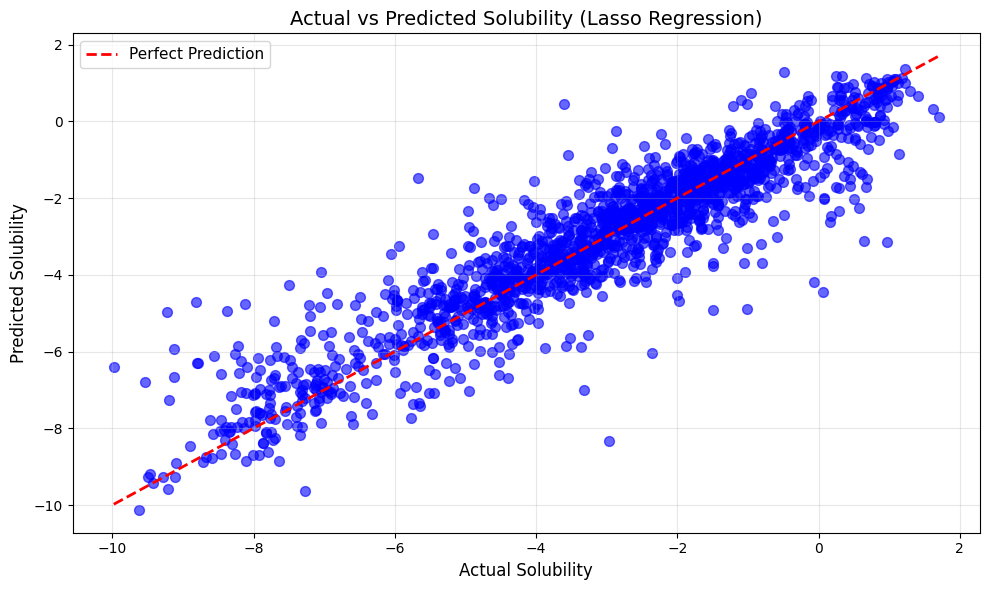

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_clean, y_pred, alpha=0.6, color='blue', s=50)
plt.plot([y_test_clean.min(), y_test_clean.max()], [y_test_clean.min(), y_test_clean.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Solubility', fontsize=12)
plt.ylabel('Predicted Solubility', fontsize=12)
plt.title('Actual vs Predicted Solubility (Lasso Regression)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Отпечатки Моргана (ECFP)

In [26]:
# Используем PandasTools из RDKit для добавления нового столбца с молекулами в DataFrame
# AddMoleculeColumnToFrame — функция, которая:
#   - берёт SMILES из указанного столбца ('SMILES'),
#   - преобразует их в объекты молекул (типа rdkit.Chem.rdchem.Mol),
#   - и добавляет их как новый столбец с именем 'Molecule'
PandasTools.AddMoleculeColumnToFrame(aqsoldb, smilesCol='SMILES', molCol='Molecule')

In [27]:
# Добавляем новый столбец 'fp' (fingerprint — фингерпринт) в датафрейм aqsoldb
# Для каждой молекулы в столбце 'Molecule' вычисляем Morgan-фингерпринт

aqsoldb['fp'] = aqsoldb['Molecule'].apply(
    # Используем lambda-функцию для применения GetMorganFingerprintAsBitVect ко всем молекулам
    lambda m: AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=1024) #Выберем радиус 2 и 1024 бита в отпечатке моргана
)

In [28]:
#Снова разобьем на трейн и тест, на этот раз используя колонки таблицы
X_train, X_test, y_train, y_test = train_test_split(aqsoldb['fp'], aqsoldb['Solubility'], test_size=0.2, random_state=42)

In [29]:
# Преобразуем каждый фингерпринт в X_train в NumPy-массив.
# Это нужно для совместимости с библиотеками машинного обучения, такими как scikit-learn.
X_train_fp = [np.array(x) for x in X_train]

# Преобразуем список целевых значений (растворимости) в NumPy-массив
y_train = np.array(y_train)

# То же самое делаем с тестовой выборкой:
X_test_fp = [np.array(x) for x in X_test]
y_test = np.array(y_test)

Теперь всё готово для обучения моделей аналогично экспериментам с дескрипторами

In [32]:
linear = LinearRegression()
linear.fit(X_train_fp, y_train)
y_pred_linear = linear.predict(X_test_fp)

print("Linear Regression:")
print("  Test MSE:", mean_squared_error(y_test, y_pred_linear))
print("  Test R2:", r2_score(y_test, y_pred_linear))


tree_model = RandomForestRegressor(random_state=42)
tree_model.fit(X_train_fp, y_train)
y_pred_tree = tree_model.predict(X_test_fp)

print("RandomForestRegressor:")
print("  Test MSE:", mean_squared_error(y_test, y_pred_tree))
print("  Test R2:", r2_score(y_test, y_pred_tree))

model = xgb.XGBRegressor(random_state=42)

model.fit(X_train_fp, y_train)
y_pred = model.predict(X_test_fp)

print("XGBRegressor:")
print("  Test MSE:", mean_squared_error(y_test, y_pred))
print("  Test R2:", r2_score(y_test, y_pred))

Linear Regression:
  Test MSE: 2.2501261237132404
  Test R2: 0.5849688044919774
RandomForestRegressor:
  Test MSE: 1.7553145376636625
  Test R2: 0.676235797015259
XGBRegressor:
  Test MSE: 1.7488893764829005
  Test R2: 0.6774209049512457


## Последнее - обучимся на комбинации ECFP + 5 дескрипторов

In [37]:
def calculate_5_descriptors(mol):
    
    logp = Descriptors.MolLogP(mol)
    molwt = Descriptors.ExactMolWt(mol)
    hbd = rdMolDescriptors.CalcNumHBD(mol)
    hba = rdMolDescriptors.CalcNumHBA(mol)
    tpsa = Descriptors.TPSA(mol)  
    
    return [logp, molwt, hbd, hba, tpsa]

desc_df = aqsoldb['Molecule'].apply(calculate_5_descriptors).apply(pd.Series)
desc_df.columns = ['LogP', 'MolWt', 'HBD', 'HBA', 'TPSA']


# Матрица отпечатков (N, 1024)
fp_matrix = np.vstack(aqsoldb['Molecule'].apply( lambda m: AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=1024)))



In [38]:
y = aqsoldb['Solubility'].values

indices = np.arange(len(aqsoldb))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

#Получаем сырые данные для train и test
y_train_raw = y[train_idx]
y_test_raw = y[test_idx]

fp_train_raw = fp_matrix[train_idx]
fp_test_raw = fp_matrix[test_idx]

desc_train_raw = desc_df.values[train_idx]
desc_test_raw = desc_df.values[test_idx]

# Ищем строки, где есть NaN в дескрипторах 
train_nan_mask = np.isnan(desc_train_raw).any(axis=1)
test_nan_mask = np.isnan(desc_test_raw).any(axis=1)

# Очищаем данные
fp_train_clean = fp_train_raw[~train_nan_mask]
desc_train_clean = desc_train_raw[~train_nan_mask]
y_train_clean = y_train_raw[~train_nan_mask]

fp_test_clean = fp_test_raw[~test_nan_mask]
desc_test_clean = desc_test_raw[~test_nan_mask]
y_test_clean = y_test_raw[~test_nan_mask]


In [39]:
# Масштабирование ТОЛЬКО для дескрипторов

scaler = StandardScaler()

desc_train_scaled = scaler.fit_transform(desc_train_clean)
desc_test_scaled = scaler.transform(desc_test_clean)


# Финальная сборка признаков (Биты + дескрипторы) 

# Конкатенируем по оси 1 (столбцы): [1024 бита | 5 дескрипторов]
X_train_final = np.hstack([fp_train_clean, desc_train_scaled])
X_test_final = np.hstack([fp_test_clean, desc_test_scaled])


In [40]:


# Linear Regression 
linear = LinearRegression()
linear.fit(X_train_final, y_train_clean)
y_pred_linear = linear.predict(X_test_final)

print("Linear Regression (ECFP + Scaled 5 Desc):")
print(f"  Test MSE: {mean_squared_error(y_test_clean, y_pred_linear):.4f}")
print(f"  Test R2:  {r2_score(y_test_clean, y_pred_linear):.4f}")
print("-" * 30)

# --- Модель 2: Random Forest ---
tree_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
tree_model.fit(X_train_final, y_train_clean)
y_pred_tree = tree_model.predict(X_test_final)

print("RandomForestRegressor (ECFP + Scaled 5 Desc):")
print(f"  Test MSE: {mean_squared_error(y_test_clean, y_pred_tree):.4f}")
print(f"  Test R2:  {r2_score(y_test_clean, y_pred_tree):.4f}")
print("-" * 30)

# --- Модель 3: XGBoost ---
xgb_model = xgb.XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=6)
xgb_model.fit(X_train_final, y_train_clean)
y_pred_xgb = xgb_model.predict(X_test_final)

print("XGBRegressor (ECFP + Scaled 5 Desc):")
print(f"  Test MSE: {mean_squared_error(y_test_clean, y_pred_xgb):.4f}")
print(f"  Test R2:  {r2_score(y_test_clean, y_pred_xgb):.4f}")

Linear Regression (ECFP + Scaled 5 Desc):
  Test MSE: 2.0864
  Test R2:  0.6152
------------------------------
RandomForestRegressor (ECFP + Scaled 5 Desc):
  Test MSE: 1.1518
  Test R2:  0.7876
------------------------------
XGBRegressor (ECFP + Scaled 5 Desc):
  Test MSE: 1.1129
  Test R2:  0.7947
